<a href="https://colab.research.google.com/github/tatsuro-jp-oka/gnn-fea-surrogate/blob/main/gnn_surrogate_fea_connecting_rod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# ============================================================
# 【セル1】 インストール
#  ※ ランタイム → ランタイムのタイプを変更 → T4 GPU を選択しておく
# ============================================================
!pip install -q nvidia-physicsnemo gmsh scikit-fem meshio torch-geometric
!apt-get install -y -qq libglu1-mesa libxrender1 libxcursor1 libxft2 libxinerama1 > /dev/null 2>&1

import torch, physicsnemo
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("physicsnemo:", physicsnemo.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.7/138.7 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/

In [10]:
!apt-get update -qq
!apt-get install -y -qq libglu1-mesa libgl1-mesa-glx xvfb \
libxrender1 libxcursor1 libxft2 libxinerama1
!pip install gmsh pyvista meshio scipy imageio imageio-ffmpeg pillow scikit-fem -q


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.5/178.5 kB 15.1 MB/s eta 0:00:00


In [28]:
# ============================================================
# コンロッド: LHS形状生成 → FEM解析
#   左: 応力分布（等角 / 上面 / 側面）
#   右: 最大応力 vs 質量 散布図（連動ハイライト）
#   をMP4動画化（肉抜き穴=Y方向/側面）
# ============================================================
# 事前に一度だけ（別セル）:
#   !apt-get update -qq
#   !apt-get install -y -qq libglu1-mesa libgl1-mesa-glx xvfb \
#       libxrender1 libxcursor1 libxft2 libxinerama1
#   !pip install gmsh pyvista meshio scipy imageio imageio-ffmpeg pillow scikit-fem matplotlib -q
# ============================================================

import os, gc, glob
import numpy as np
import gmsh, meshio
import pyvista as pv
import imageio.v2 as imageio
from scipy.stats import qmc
from PIL import Image
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import skfem
from skfem import MeshTet, Basis, ElementVector, ElementTetP1, asm, condense, solve
from skfem.helpers import sym_grad, trace, eye, ddot

os.environ["DISPLAY"] = ":99"
os.system("Xvfb :99 -screen 0 1280x800x24 &")
pv.OFF_SCREEN = True

# ============================================================
FIXED = {
    "L": 140.0, "d_small": 22.0, "D_small": 34.0,
    "d_big": 48.0, "D_big": 66.0, "w_small": 20.0, "w_big": 26.0,
}
SWEEP_RANGES = {
    "h_web"         : (4.0, 10.0),
    "t_flange"      : (3.0, 5.5),
    "b_shank_big"   : (18.0, 26.0),
    "b_shank_small" : (12.0, 18.0),
    "w_shank_big"   : (16.0, 24.0),
    "w_shank_small" : (10.0, 16.0),
    "hole_d"        : (4.0, 9.0),
    "hole_margin"   : (18.0, 28.0),
}
N_HOLES, N_MODELS, MESH, SEED = 3, 30, 3.0, 42
E, NU   = 205.0e3, 0.29
RHO     = 7.85e-6
F_TOTAL = 20000.0
OUT_MP4, FPS = "conrod_views_graph.mp4", 8

# ============================================================
def make_lhs_samples():
    keys  = list(SWEEP_RANGES.keys())
    lows  = np.array([SWEEP_RANGES[k][0] for k in keys])
    highs = np.array([SWEEP_RANGES[k][1] for k in keys])
    s = qmc.LatinHypercube(d=len(keys), seed=SEED)
    scaled = qmc.scale(s.random(n=N_MODELS), lows, highs)
    out = []
    for row in scaled:
        d = dict(FIXED)
        for k, v in zip(keys, row): d[k] = float(v)
        d["n_holes"] = N_HOLES
        out.append(d)
    return out, keys

# ============================================================
def build(P, mesh_size, msh="conrod.msh"):
    if os.path.exists(msh): os.remove(msh)
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0)
    gmsh.model.add("conrod")
    occ = gmsh.model.occ
    try:
        x_big, x_small = 0.0, P["L"]
        big_solid   = occ.addCylinder(x_big,   0, -P["w_big"]/2,   0,0,P["w_big"],   P["D_big"]/2)
        small_solid = occ.addCylinder(x_small, 0, -P["w_small"]/2, 0,0,P["w_small"], P["D_small"]/2)

        x0, x1 = 2.0, P["L"] - 2.0
        Lsh = x1 - x0

        # I断面の向き: フランジ離れ=Y（揺動面内）, 板厚=Z（ピン軸方向）
        def rect_wire(xc, b_flange_dir, w_web_dir):
            hy, hz = b_flange_dir/2.0, w_web_dir/2.0
            pt = [occ.addPoint(xc, y, z) for (y,z) in
                  [(-hy,-hz),(hy,-hz),(hy,hz),(-hy,hz)]]
            ln = [occ.addLine(pt[i], pt[(i+1)%4]) for i in range(4)]
            return occ.addWire(ln)

        wb = rect_wire(x0, P["b_shank_big"],   P["w_shank_big"])
        ws = rect_wire(x1, P["b_shank_small"], P["w_shank_small"])
        shank = occ.addThruSections([wb, ws], makeSolid=True)
        occ.synchronize()

        # I断面化: 上下（Z方向）からBoxで溝削り
        by_min = min(P["b_shank_big"], P["b_shank_small"])
        y_lo, y_hi = -by_min/2 + P["t_flange"], by_min/2 - P["t_flange"]
        web_h = y_hi - y_lo
        if web_h > 0:
            wz_max = max(P["w_shank_big"], P["w_shank_small"])
            gt = occ.addBox(x0-1, y_lo,  P["h_web"]/2,          Lsh+2, web_h, wz_max)
            gb = occ.addBox(x0-1, y_lo, -wz_max - P["h_web"]/2, Lsh+2, web_h, wz_max)
            occ.synchronize()
            shank = occ.cut(shank, [(3,gt),(3,gb)])[0]
            occ.synchronize()

        fused, _ = occ.fuse([(3,big_solid)], [(3,small_solid)] + shank)
        occ.synchronize()

        # 内穴を後から開ける
        bore_b = occ.addCylinder(x_big,   0, -P["w_big"]/2-1,   0,0,P["w_big"]+2,   P["d_big"]/2)
        bore_s = occ.addCylinder(x_small, 0, -P["w_small"]/2-1, 0,0,P["w_small"]+2, P["d_small"]/2)
        occ.synchronize()
        fused = occ.cut(fused, [(3,bore_b),(3,bore_s)])[0]
        occ.synchronize()

        # （肉抜き穴は作らない）

        occ.removeAllDuplicates(); occ.synchronize()
        gmsh.option.setNumber("Mesh.MeshSizeMin", mesh_size*0.5)
        gmsh.option.setNumber("Mesh.MeshSizeMax", mesh_size)
        gmsh.option.setNumber("Mesh.Algorithm3D", 1)
        gmsh.model.mesh.generate(3)
        _, et, _ = gmsh.model.mesh.getElements(dim=3)
        if sum(len(t) for t in et) == 0:
            raise RuntimeError("メッシュ失敗")
        gmsh.write(msh)
    finally:
        gmsh.finalize()
    return msh



# ============================================================
def load_meshes(msh_file):
    m = meshio.read(msh_file)
    pts = m.points
    tets = next((c.data for c in m.cells if c.type == "tetra"), None)
    if tets is None or len(tets) == 0:
        raise RuntimeError("四面体なし")
    fem_mesh = MeshTet(pts.T, tets.T)
    cells  = np.hstack([np.full((len(tets),1), 4), tets]).astype(np.int64).ravel()
    ctypes = np.full(len(tets), pv.CellType.TETRA, dtype=np.uint8)
    pv_grid = pv.UnstructuredGrid(cells, ctypes, pts)
    return fem_mesh, pv_grid, pts, tets

def tet_volume_total(pts, tets):
    p = pts[tets]
    v0 = p[:,1]-p[:,0]; v1 = p[:,2]-p[:,0]; v2 = p[:,3]-p[:,0]
    return (np.abs(np.einsum('ij,ij->i', np.cross(v0, v1), v2)) / 6.0).sum()

# ============================================================
def solve_stress(fem_mesh, pts, tets, P):
    e = ElementVector(ElementTetP1())
    basis = Basis(fem_mesh, e)
    lam = E*NU/((1+NU)*(1-2*NU)); mu = E/(2*(1+NU))
    @skfem.BilinearForm
    def stiffness(u, v, w):
        eps = sym_grad(u)
        C = 2.0*mu*eps + lam*eye(trace(eps), eps.shape[0])
        return ddot(C, sym_grad(v))
    K = asm(stiffness, basis)
    x, y, z = fem_mesh.p
    r_big = np.sqrt(x**2 + y**2)
    fixed = np.where((np.abs(x) < P["d_big"]/2+2.0) &
                     (r_big > P["d_big"]/2-1.5) & (r_big < P["d_big"]/2+2.5))[0]
    r_small = np.sqrt((x-P["L"])**2 + y**2)
    load = np.where((np.abs(x-P["L"]) < P["d_small"]/2+2.0) &
                    (r_small > P["d_small"]/2-1.5) & (r_small < P["d_small"]/2+2.0))[0]
    if len(fixed) == 0 or len(load) == 0:
        raise RuntimeError("境界節点なし")
    fixed_dofs = np.concatenate([3*fixed, 3*fixed+1, 3*fixed+2])
    f = np.zeros(K.shape[0]); f[3*load] = -F_TOTAL/len(load)
    u = solve(*condense(K, f, D=fixed_dofs))
    n = pts.shape[0]; U = u.reshape(n, 3)
    vm_elem = np.zeros(len(tets))
    for i, tet in enumerate(tets):
        M = np.hstack([np.ones((4,1)), pts[tet]])
        try: grad = np.linalg.inv(M)[1:, :]
        except np.linalg.LinAlgError: continue
        gU = grad @ U[tet]; eps = 0.5*(gU+gU.T)
        s = lam*np.trace(eps)*np.eye(3) + 2*mu*eps
        vm_elem[i] = np.sqrt(0.5*((s[0,0]-s[1,1])**2+(s[1,1]-s[2,2])**2+
                             (s[2,2]-s[0,0])**2)+3*(s[0,1]**2+s[1,2]**2+s[2,0]**2))
    vm_node = np.zeros(n); cnt = np.zeros(n)
    for i, tet in enumerate(tets):
        vm_node[tet] += vm_elem[i]; cnt[tet] += 1
    cnt[cnt==0] = 1
    return U, vm_node/cnt

# ============================================================
# 応力ビュー1枚
# ============================================================
def stress_view(pv_grid, U, vm_node, vmax, view, title,
                scale=40.0, size=(560, 360), bar=False):
    grid = pv_grid.copy()
    grid["vm"] = vm_node
    grid.points = pv_grid.points + U*scale
    pl = pv.Plotter(off_screen=True, window_size=list(size))
    pl.add_mesh(grid, scalars="vm", cmap="jet", clim=[0, vmax],
                show_scalar_bar=bar,
                scalar_bar_args={"title": "von Mises [MPa]"} if bar else None)
    pl.set_background("white")
    pl.add_text(title, position="upper_left", font_size=10, color="black")
    if   view == "iso":  pl.camera_position = "iso"
    elif view == "top":  pl.view_xy()
    elif view == "side": pl.view_xz()
    pl.reset_camera(); pl.camera.zoom(1.15)
    img = pl.screenshot(return_img=True)
    pl.close(); pl.deep_clean(); del pl, grid
    return img

def render_scatter_png(mass_arr, smax_arr, cur, fname, size=(520, 760)):
    fig, ax = plt.subplots(figsize=(size[0]/100, size[1]/100), dpi=100)
    ax.scatter(mass_arr, smax_arr, c="lightgray", edgecolor="gray",
               s=60, zorder=2, label="all models")
    ax.scatter([mass_arr[cur]], [smax_arr[cur]], c="red", edgecolor="black",
               s=170, zorder=3, label="current")
    ax.annotate(f"#{cur+1}", (mass_arr[cur], smax_arr[cur]),
                textcoords="offset points", xytext=(8,8), color="red", fontsize=11)
    ax.set_xlabel("Mass [kg]"); ax.set_ylabel("Max von Mises [MPa]")
    ax.set_title("Max stress vs Mass")
    ax.grid(alpha=0.3); ax.legend(loc="best")
    fig.tight_layout(); fig.savefig(fname); plt.close(fig)

# ============================================================
# 左: 等角+上面+側面（縦積み） / 右: 散布図
# ============================================================
def render_frame(pv_grid, U, vm, idx, P, mass_arr, smax_arr, vmax, fname):
    iso  = stress_view(pv_grid, U, vm, vmax, "iso",  f"Iso (Model {idx+1})", bar=True)
    top  = stress_view(pv_grid, U, vm, vmax, "top",  "Top (XY)")
    side = stress_view(pv_grid, U, vm, vmax, "side", "Side (XZ)")

    ims = [Image.fromarray(a) for a in (iso, top, side)]
    w = max(im.width for im in ims)
    h = sum(im.height for im in ims)
    left = Image.new("RGB", (w, h), "white")
    y = 0
    for im in ims:
        left.paste(im, ((w-im.width)//2, y)); y += im.height

    fR = fname.replace(".png", "_sc.png")
    render_scatter_png(mass_arr, smax_arr, idx, fR, size=(560, left.height))
    imgR = Image.open(fR)

    canvas = Image.new("RGB", (left.width + imgR.width,
                               max(left.height, imgR.height)), "white")
    canvas.paste(left, (0, 0))
    canvas.paste(imgR, (left.width, (canvas.height-imgR.height)//2))
    canvas.save(fname)
    del left, imgR; gc.collect()

# ============================================================
# メイン
# ============================================================
if __name__ == "__main__":
    samples, keys = make_lhs_samples()
    print(f"LHS {len(samples)} 件。解析開始（上面+側面+グラフ）。")
    os.makedirs("fr", exist_ok=True)
    for f in glob.glob("fr/*.png"): os.remove(f)

    results = []
    vmax_all = 0.0
    for i, P in enumerate(samples):
        try:
            msh = build(P, MESH)
            fem_mesh, pv_grid, pts, tets = load_meshes(msh)
            U, vm = solve_stress(fem_mesh, pts, tets, P)
            mass = tet_volume_total(pts, tets) * RHO
            smax = float(np.percentile(vm, 99.5))
            results.append((P, pv_grid, U, vm, mass, smax))
            vmax_all = max(vmax_all, smax)
        except (Exception, SystemExit) as ex:
            print(f"  model {i+1}: skip ({type(ex).__name__}: {ex})")
            try: gmsh.finalize()
            except Exception: pass
        if (i+1) % 5 == 0:
            print(f"  {i+1}/{N_MODELS} 完了（成功 {len(results)}）")

    if not results:
        raise SystemExit("成功モデルがありません。")

    vmax = vmax_all * 1.05
    mass_arr = np.array([r[4] for r in results])
    smax_arr = np.array([r[5] for r in results])
    print(f"成功 {len(results)} 件。color上限 {vmax:.0f} MPa。フレーム作成中...")

    frame_files = []
    for idx, (P, pv_grid, U, vm, mass, smax) in enumerate(results):
        fC = f"fr/frame_{idx:03d}.png"
        render_frame(pv_grid, U, vm, idx, P, mass_arr, smax_arr, vmax, fC)
        frame_files.append(fC)

    print(f"MP4書き出し中... ({len(frame_files)} フレーム)")
    with imageio.get_writer(OUT_MP4, fps=FPS, codec="libx264",
                            quality=8, macro_block_size=None) as w:
        for fn in frame_files:
            w.append_data(imageio.imread(fn))
    print(f"完了 → {OUT_MP4}")

    from IPython.display import HTML
    from base64 import b64encode
    data = b64encode(open(OUT_MP4, "rb").read()).decode()
    display(HTML(f'<video width=1000 controls autoplay loop>'
                 f'<source src="data:video/mp4;base64,{data}" type="video/mp4"></video>'))


LHS 30 件。解析開始（上面+側面+グラフ）。



  5/30 完了（成功 5）



  10/30 完了（成功 10）



  15/30 完了（成功 15）



  20/30 完了（成功 20）



  25/30 完了（成功 25）



  30/30 完了（成功 30）
成功 30 件。color上限 177 MPa。フレーム作成中...
MP4書き出し中... (30 フレーム)
完了 → conrod_views_graph.mp4


device: cuda
グラフ数: 30
学習 24 / 検証 6
Epoch   25 | train 8.799e-01 | val 2.567e-01 | Patience 0/100
Epoch   50 | train 1.055e+00 | val 3.971e-01 | Patience 14/100
Epoch   75 | train 7.255e-01 | val 2.039e-01 | Patience 3/100
Epoch  100 | train 8.047e-01 | val 1.820e-01 | Patience 14/100
Epoch  125 | train 6.683e-01 | val 3.836e-01 | Patience 6/100
Epoch  150 | train 7.927e-01 | val 1.465e-01 | Patience 0/100
Epoch  175 | train 4.834e-01 | val 2.259e-01 | Patience 12/100
Epoch  200 | train 5.625e-01 | val 1.608e-01 | Patience 15/100
Epoch  225 | train 5.625e-01 | val 3.191e-01 | Patience 11/100
Epoch  250 | train 4.844e-01 | val 1.331e-01 | Patience 0/100
Epoch  275 | train 4.422e-01 | val 1.480e-01 | Patience 4/100
Epoch  300 | train 4.606e-01 | val 1.695e-01 | Patience 15/100
Epoch  325 | train 4.568e-01 | val 1.465e-01 | Patience 11/100
Epoch  350 | train 3.934e-01 | val 1.746e-01 | Patience 2/100
Epoch  375 | train 3.907e-01 | val 1.246e-01 | Patience 14/100
Epoch  400 | train 3.910e-0

/tmp/ipykernel_655/1990401848.py:198: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


  val#0 (model 26): relative L2 = 0.220
  val#1 (model 4): relative L2 = 0.193
  val#2 (model 1): relative L2 = 0.212
  val#3 (model 22): relative L2 = 0.198
  val#4 (model 16): relative L2 = 0.203
  val#5 (model 13): relative L2 = 0.243

検証平均 relative L2 誤差: 0.211


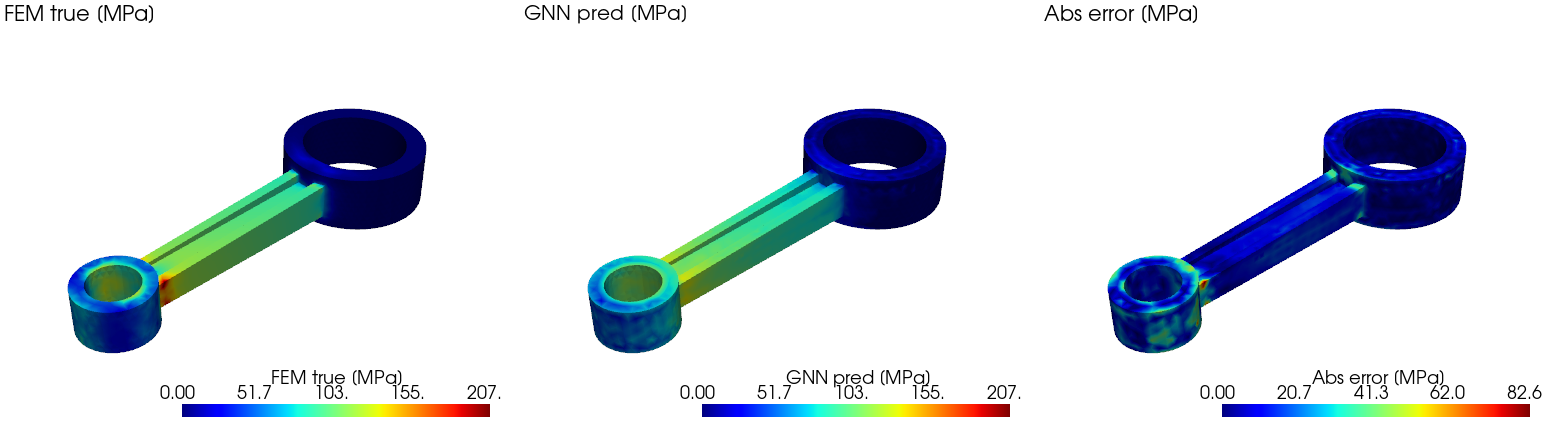

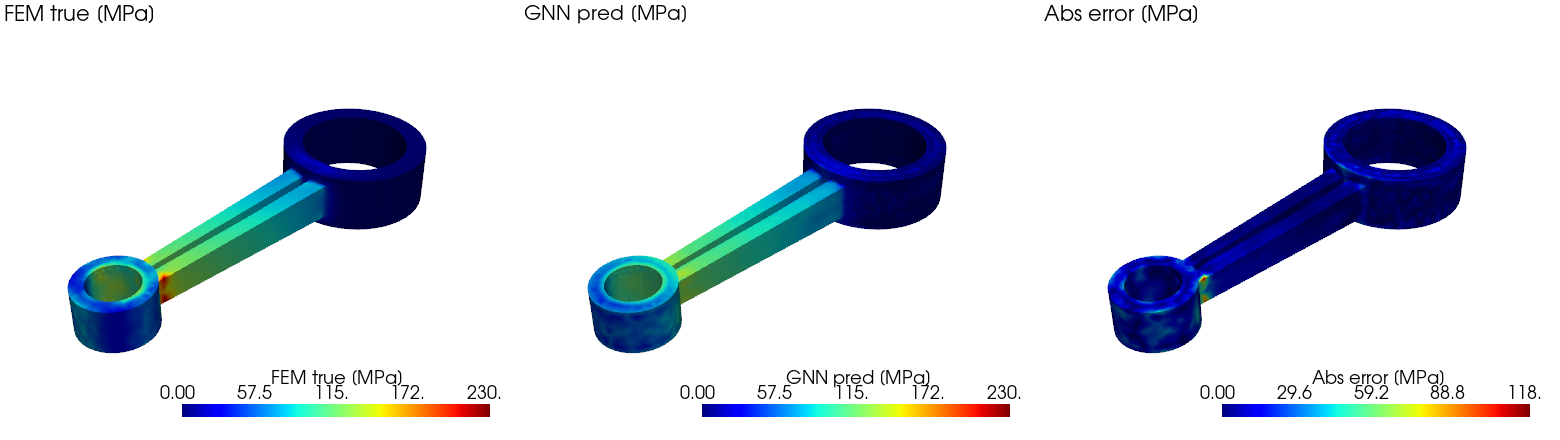

In [26]:
# ============================================================
# 【新セル】 コンロッド解析結果を GNN で学習（80%学習/20%検証）
#   - 各モデルのメッシュをグラフ化（ノード=節点, エッジ=四面体の辺）
#   - ノード特徴: 座標 + 境界条件フラグ（拘束/荷重）
#   - 出力: 節点フォン・ミーゼス応力
#   - 検証結果を 真値 vs 予測 vs 誤差 で可視化
# ============================================================
# 事前（別セル）:
#   !pip install torch torch-geometric -q
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GraphConv
import matplotlib.pyplot as plt
import pyvista as pv

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ------------------------------------------------------------
# 1. results からグラフデータを構築
#    results: list of (P, pv_grid, U, vm, mass, smax)  ← 前のセルで作成済み
# ------------------------------------------------------------
def tets_to_edges(tets):
    """四面体配列 → 無向エッジ index (2, E)"""
    e = []
    pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
    for a, b in pairs:
        e.append(tets[:, [a, b]])
    edges = np.vstack(e)
    edges = np.vstack([edges, edges[:, ::-1]])     # 双方向
    edges = np.unique(edges, axis=0)
    return edges.T

def build_graph(P, pts, tets, vm):
    # ノード特徴: 正規化座標(x,y,z) + 拘束フラグ + 荷重フラグ
    x, y, z = pts[:,0], pts[:,1], pts[:,2]
    r_big   = np.sqrt(x**2 + y**2)
    r_small = np.sqrt((x-P["L"])**2 + y**2)
    fixed = ((np.abs(x) < P["d_big"]/2+2.0) &
             (r_big > P["d_big"]/2-1.5) & (r_big < P["d_big"]/2+2.5)).astype(np.float32)
    load  = ((np.abs(x-P["L"]) < P["d_small"]/2+2.0) &
             (r_small > P["d_small"]/2-1.5) & (r_small < P["d_small"]/2+2.0)).astype(np.float32)
    # 座標は形状全体で正規化（L基準）
    feats = np.stack([x/P["L"], y/P["L"], z/P["L"], fixed, load], axis=1).astype(np.float32)

    edge_index = tets_to_edges(tets.astype(np.int64))
    data = Data(
        x=torch.tensor(feats),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        y=torch.tensor(vm.astype(np.float32)).unsqueeze(1),
    )
    return data

# resultsから (P, pts, tets, vm) を再取得（pv_gridに座標、別途tetsが必要）
# 前セルのloopでtetsを保存していない場合に備え、ここでmshから再読込する手もあるが
# results内のpv_gridからcells情報を復元する
def grid_to_pts_tets(pv_grid):
    pts = np.asarray(pv_grid.points)
    cells = pv_grid.cells.reshape(-1, 5)   # [4, n0,n1,n2,n3]
    tets = cells[:, 1:5]
    return pts, tets

graphs = []
for (P, pv_grid, U, vm, mass, smax) in results:
    pts, tets = grid_to_pts_tets(pv_grid)
    graphs.append(build_graph(P, pts, tets, vm))

print(f"グラフ数: {len(graphs)}")

# 応力の正規化（全グラフ共通スケール）
all_y = torch.cat([g.y for g in graphs])
y_mean, y_std = all_y.mean().item(), all_y.std().item() + 1e-8
for g in graphs:
    g.y = (g.y - y_mean) / y_std

# ------------------------------------------------------------
# 2. 80% 学習 / 20% 検証 に分割
# ------------------------------------------------------------
n = len(graphs)
idx = np.random.permutation(n)
n_tr = int(0.8 * n)
train_graphs = [graphs[i] for i in idx[:n_tr]]
val_graphs   = [graphs[i] for i in idx[n_tr:]]
val_idx      = idx[n_tr:]   # 元resultsでの位置（可視化用）
print(f"学習 {len(train_graphs)} / 検証 {len(val_graphs)}")

train_dl = DataLoader(train_graphs, batch_size=4, shuffle=True)
val_dl   = DataLoader(val_graphs,   batch_size=1)

# ------------------------------------------------------------
# 3. GNN モデルと重み付き損失関数
# ------------------------------------------------------------
class StressGNN(nn.Module):
    def __init__(self, in_dim=5, h=128):
        super().__init__()
        self.enc = nn.Linear(in_dim, h)
        # GraphConvのままでも良いですが、応力集中に注目しやすくするため
        # 隠れ層の次元数を維持しつつ、そのまま利用します
        self.c1 = GraphConv(h, h)
        self.c2 = GraphConv(h, h)
        self.c3 = GraphConv(h, h)
        self.c4 = GraphConv(h, h)
        self.dec = nn.Sequential(nn.Linear(h, h), nn.GELU(), nn.Linear(h, 1))

    def forward(self, data):
        x, ei = data.x, data.edge_index
        h = F.gelu(self.enc(x))
        h = F.gelu(self.c1(h, ei)) + h
        h = F.gelu(self.c2(h, ei)) + h
        h = F.gelu(self.c3(h, ei)) + h
        h = F.gelu(self.c4(h, ei)) + h
        return self.dec(h)

model = StressGNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sch = torch.optim.lr_scheduler.StepLR(opt, step_size=150, gamma=0.5)

# 【追加】重み付き損失関数（高応力ノードの誤差を重視）
def weighted_mse_loss(pred, target, alpha=3.0):
    # targetは正規化済み（平均0, 分散1）。0以上は平均より高い応力を意味する。
    # 応力が高いほど loss に掛かる重みが大きくなる
    weight = 1.0 + torch.relu(target) * alpha
    loss = weight * (pred - target)**2
    return loss.mean()

# ------------------------------------------------------------
# 4. 学習（アーリーストップ＆ベストモデル保存機能付き）
# ------------------------------------------------------------
EPOCHS = 2000
PATIENCE = 100 # 100エポック改善がなければストップ
best_val_loss = float('inf')
patience_counter = 0
best_model_path = "best_gnn_model.pth"

hist_tr, hist_va = [], []

for ep in range(EPOCHS):
    model.train()
    tl = 0; ntr = 0
    for batch in train_dl:
        batch = batch.to(device)
        opt.zero_grad()
        out = model(batch)
        # 損失関数を weighted_mse_loss に変更
        l = weighted_mse_loss(out, batch.y, alpha=3.0)
        l.backward()
        opt.step()
        tl += l.item() * batch.num_graphs
        ntr += batch.num_graphs
    tl /= ntr
    sch.step()

    model.eval()
    vl = 0; nv = 0
    with torch.no_grad():
        for batch in val_dl:
            batch = batch.to(device)
            # 検証時も同じ重み付きLoss、または純粋なMSELossで評価（今回はMSEで評価）
            vl += F.mse_loss(model(batch), batch.y).item() * batch.num_graphs
            nv += batch.num_graphs
    vl /= nv

    hist_tr.append(tl)
    hist_va.append(vl)

    # 【追加】ベストモデル保存とアーリーストップ判定
    if vl < best_val_loss:
        best_val_loss = vl
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path) # ベストモデルを保存
    else:
        patience_counter += 1

    if (ep+1) % 25 == 0:
        print(f"Epoch {ep+1:4d} | train {tl:.3e} | val {vl:.3e} | Patience {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {ep+1}. Best Val Loss: {best_val_loss:.3e}")
        break

# 学習曲線の描画
plt.figure(figsize=(6,4))
plt.semilogy(hist_tr, label="train (Weighted MSE)")
plt.semilogy(hist_va, label="val (MSE)")
plt.axvline(x=len(hist_tr) - patience_counter - 1, color='r', linestyle='--', label='Best Model')
plt.xlabel("epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("GNN training history with Early Stopping")
plt.tight_layout()
plt.show()

# 【追加】検証・推論の前にベストモデルをロードする
print(f"Loading best model from {best_model_path}...")
model.load_state_dict(torch.load(best_model_path))

# ------------------------------------------------------------
# 5. 検証データの可視化（真値 vs 予測 vs 誤差）
# ------------------------------------------------------------
# (これ以降は元のコードと同じです)

# ------------------------------------------------------------
# 5. 検証データの可視化（真値 vs 予測 vs 誤差）
#    PyVistaで3D応力分布を3枚並べて1検証モデルを表示
# ------------------------------------------------------------
pv.OFF_SCREEN = True
from PIL import Image

def visualize_val(g, orig_index, fname):
    model.eval()
    with torch.no_grad():
        pred_n = model(g.to(device)).cpu().numpy().ravel()
    true_n = g.y.cpu().numpy().ravel()
    # 逆正規化して MPa に戻す
    pred = pred_n * y_std + y_mean
    true = true_n * y_std + y_mean
    err  = np.abs(pred - true)

    P, pv_grid, U, vm, mass, smax = results[orig_index]
    vmax = max(true.max(), pred.max())

    def snap(scalars, title, vmx, cmap="jet"):
        grid = pv_grid.copy()
        grid["s"] = scalars
        pl = pv.Plotter(off_screen=True, window_size=[520, 440])
        pl.add_mesh(grid, scalars="s", cmap=cmap, clim=[0, vmx],
                    scalar_bar_args={"title": title})
        pl.set_background("white"); pl.camera_position = "iso"
        pl.reset_camera(); pl.camera.zoom(1.1)
        pl.add_text(title, position="upper_left", font_size=10, color="black")
        img = pl.screenshot(return_img=True)
        pl.close(); pl.deep_clean(); del pl, grid
        return img

    a = snap(true, "FEM true [MPa]", vmax)
    b = snap(pred, "GNN pred [MPa]", vmax)
    c = snap(err,  "Abs error [MPa]", err.max())

    ims = [Image.fromarray(x) for x in (a, b, c)]
    w = sum(im.width for im in ims); h = max(im.height for im in ims)
    canvas = Image.new("RGB", (w, h), "white")
    x = 0
    for im in ims:
        canvas.paste(im, (x, 0)); x += im.width
    canvas.save(fname)

    rel = np.linalg.norm(pred - true) / (np.linalg.norm(true) + 1e-8)
    return rel

import os
os.makedirs("gnn_val", exist_ok=True)
rels = []
print("\n=== 検証モデルの予測精度 ===")
for k, (g, oi) in enumerate(zip(val_graphs, val_idx)):
    fname = f"gnn_val/val_{k:02d}.png"
    rel = visualize_val(g, oi, fname)
    rels.append(rel)
    print(f"  val#{k} (model {oi+1}): relative L2 = {rel:.3f}")

print(f"\n検証平均 relative L2 誤差: {np.mean(rels):.3f}")

# 先頭2件をノートブックに表示
from IPython.display import display
for k in range(min(2, len(val_graphs))):
    display(Image.open(f"gnn_val/val_{k:02d}.png"))


Device: cuda
グラフ数: 30
学習 24 / 検証 6
--- Training Started ---
Epoch   50 | train(W-MSE) 4.607e-01 | val(MSE) 7.359e-02 | Patience 0/150
Epoch  100 | train(W-MSE) 4.322e-01 | val(MSE) 6.718e-02 | Patience 11/150
Epoch  150 | train(W-MSE) 3.550e-01 | val(MSE) 6.505e-02 | Patience 4/150
Epoch  200 | train(W-MSE) 2.684e-01 | val(MSE) 3.332e-02 | Patience 3/150
Epoch  250 | train(W-MSE) 2.420e-01 | val(MSE) 2.983e-02 | Patience 11/150
Epoch  300 | train(W-MSE) 2.094e-01 | val(MSE) 2.694e-02 | Patience 4/150
Epoch  350 | train(W-MSE) 2.160e-01 | val(MSE) 3.445e-02 | Patience 17/150
Epoch  400 | train(W-MSE) 1.701e-01 | val(MSE) 2.377e-02 | Patience 2/150
Epoch  450 | train(W-MSE) 1.462e-01 | val(MSE) 2.184e-02 | Patience 10/150
Epoch  500 | train(W-MSE) 1.339e-01 | val(MSE) 2.301e-02 | Patience 31/150
Epoch  550 | train(W-MSE) 1.189e-01 | val(MSE) 1.814e-02 | Patience 15/150
Epoch  600 | train(W-MSE) 1.139e-01 | val(MSE) 1.689e-02 | Patience 7/150
Epoch  650 | train(W-MSE) 1.141e-01 | val(MSE)

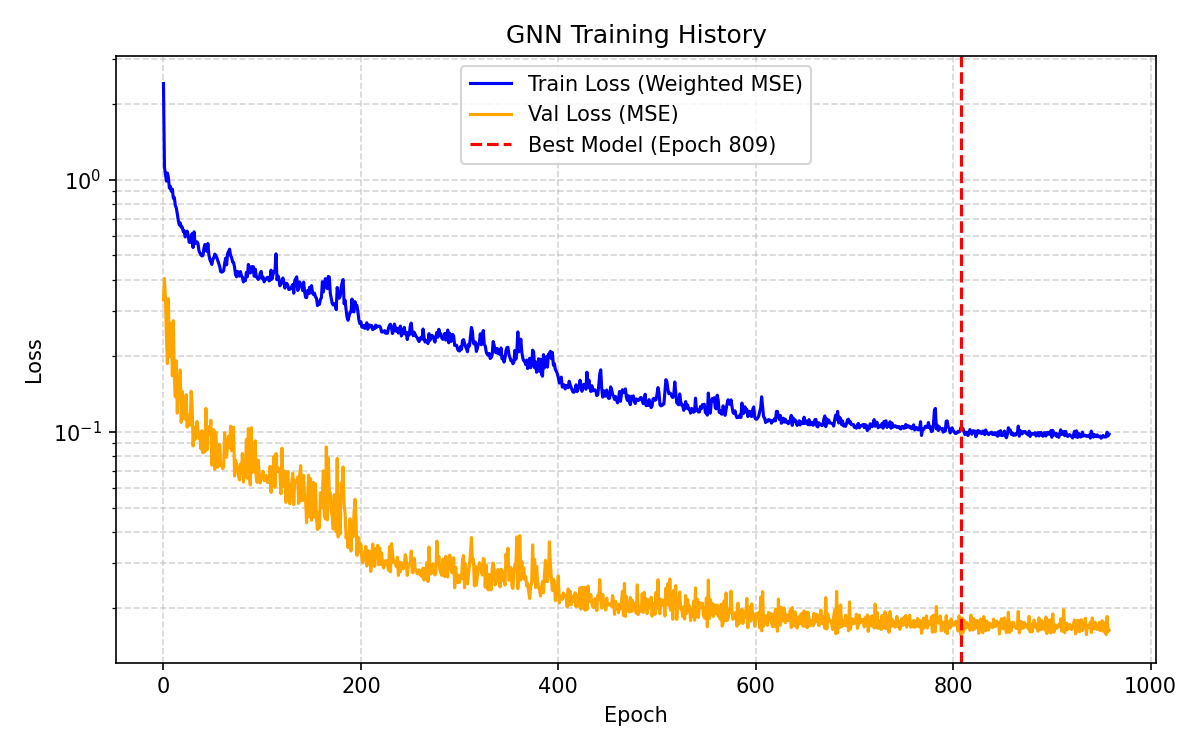


Loading best model from best_gnn_model_gat.pth...

=== 検証モデルの予測精度 ===
  val#0 (model 21): relative L2 = 0.091
  val#1 (model 8): relative L2 = 0.075
  val#2 (model 11): relative L2 = 0.079
  val#3 (model 15): relative L2 = 0.087
  val#4 (model 20): relative L2 = 0.082
  val#5 (model 7): relative L2 = 0.118

検証平均 relative L2 誤差: 0.089


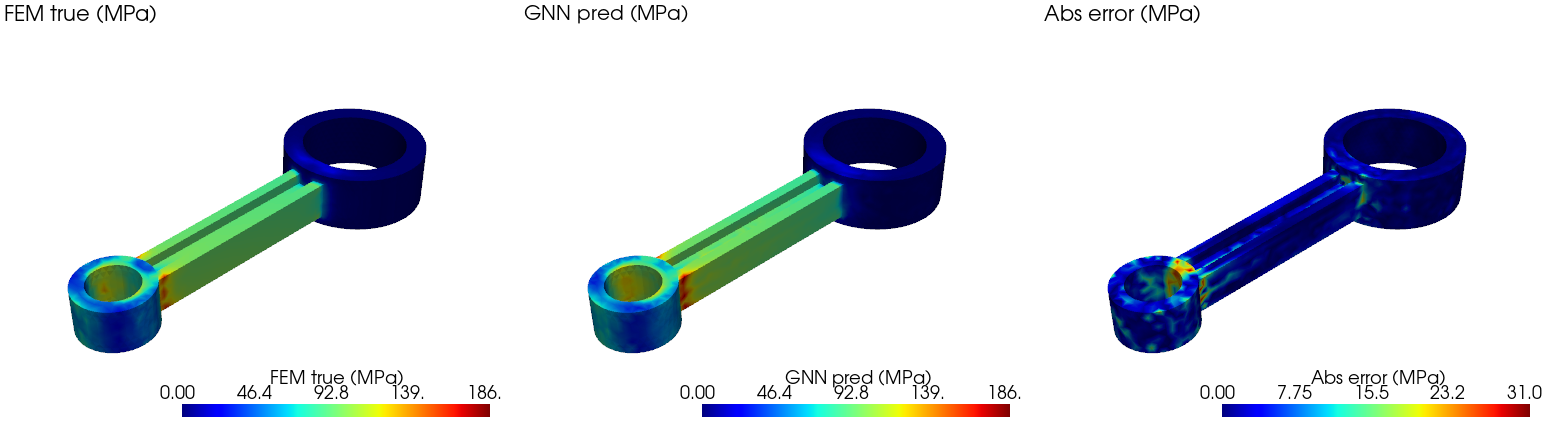

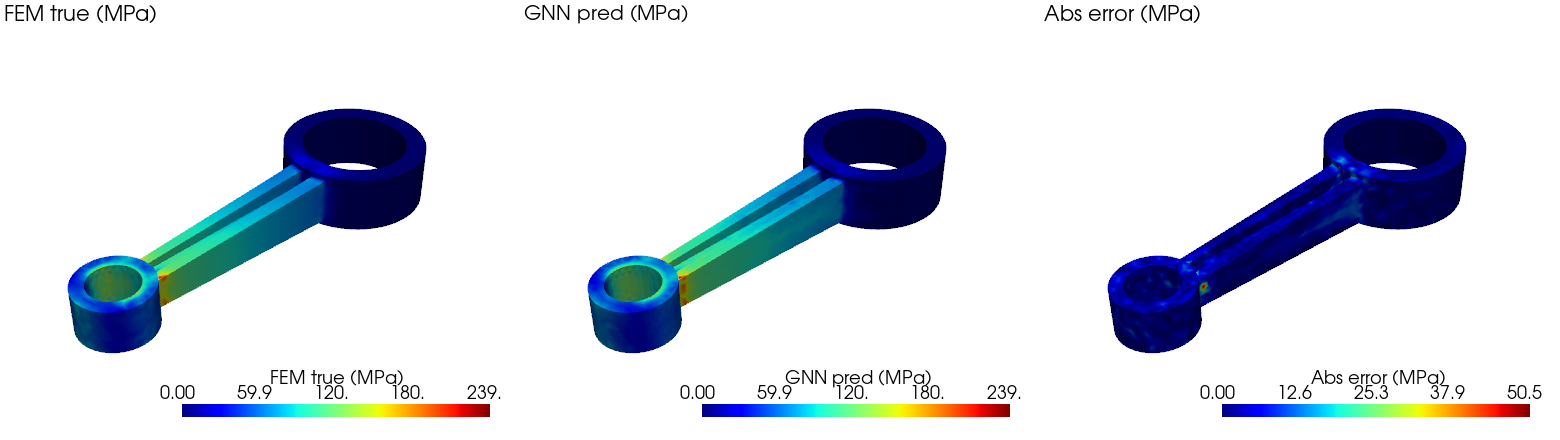

In [27]:
# ============================================================
# コンロッド解析結果 GNN学習・評価プログラム (高精度化・完全版)
# ============================================================
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, LayerNorm
import matplotlib.pyplot as plt
import pyvista as pv
from PIL import Image
from IPython.display import display

# 環境設定
pv.OFF_SCREEN = True
torch.manual_seed(42)
np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ------------------------------------------------------------
# 1. グラフデータの構築
# ------------------------------------------------------------
def tets_to_edges(tets):
    e = []
    pairs = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
    for a, b in pairs:
        e.append(tets[:, [a, b]])
    edges = np.vstack(e)
    edges = np.vstack([edges, edges[:, ::-1]])
    edges = np.unique(edges, axis=0)
    return edges.T

def build_graph(P, pts, tets, vm):
    x, y, z = pts[:,0], pts[:,1], pts[:,2]
    r_big   = np.sqrt(x**2 + y**2)
    r_small = np.sqrt((x-P["L"])**2 + y**2)

    fixed = ((np.abs(x) < P["d_big"]/2+2.0) &
             (r_big > P["d_big"]/2-1.5) & (r_big < P["d_big"]/2+2.5)).astype(np.float32)
    load  = ((np.abs(x-P["L"]) < P["d_small"]/2+2.0) &
             (r_small > P["d_small"]/2-1.5) & (r_small < P["d_small"]/2+2.0)).astype(np.float32)

    feats = np.stack([x/P["L"], y/P["L"], z/P["L"], fixed, load], axis=1).astype(np.float32)
    edge_index = tets_to_edges(tets.astype(np.int64))

    data = Data(
        x=torch.tensor(feats),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        y=torch.tensor(vm.astype(np.float32)).unsqueeze(1),
    )
    return data

def grid_to_pts_tets(pv_grid):
    pts = np.asarray(pv_grid.points)
    cells = pv_grid.cells.reshape(-1, 5)
    tets = cells[:, 1:5]
    return pts, tets

graphs = []
# ※ここでは事前のセルで作成した results リストが存在することを前提としています
for (P, pv_grid, U, vm, mass, smax) in results:
    pts, tets = grid_to_pts_tets(pv_grid)
    graphs.append(build_graph(P, pts, tets, vm))

print(f"グラフ数: {len(graphs)}")

# 応力の正規化（全グラフ共通スケール）
all_y = torch.cat([g.y for g in graphs])
y_mean, y_std = all_y.mean().item(), all_y.std().item() + 1e-8
for g in graphs:
    g.y = (g.y - y_mean) / y_std

# ------------------------------------------------------------
# 2. データ分割 (80% / 20%)
# ------------------------------------------------------------
n = len(graphs)
idx = np.random.permutation(n)
n_tr = int(0.8 * n)
train_graphs = [graphs[i] for i in idx[:n_tr]]
val_graphs   = [graphs[i] for i in idx[n_tr:]]
val_idx      = idx[n_tr:]
print(f"学習 {len(train_graphs)} / 検証 {len(val_graphs)}")

train_dl = DataLoader(train_graphs, batch_size=4, shuffle=True)
val_dl   = DataLoader(val_graphs,   batch_size=1)

# ------------------------------------------------------------
# 3. GNN モデル (GATConv + LayerNorm + Residual)
# ------------------------------------------------------------
class AttentionStressGNN(nn.Module):
    def __init__(self, in_dim=5, h=128):
        super().__init__()
        self.enc = nn.Linear(in_dim, h)
        # GATConv (Graph Attention) で応力集中部などの重要な接続を学習
        self.conv1 = GATConv(h, h, heads=2, concat=False)
        self.ln1 = LayerNorm(h)
        self.conv2 = GATConv(h, h, heads=2, concat=False)
        self.ln2 = LayerNorm(h)
        self.conv3 = GATConv(h, h, heads=2, concat=False)
        self.ln3 = LayerNorm(h)

        self.dec = nn.Sequential(
            nn.Linear(h, h),
            nn.GELU(),
            nn.Linear(h, 1)
        )

    def forward(self, data):
        x, ei = data.x, data.edge_index
        h0 = F.gelu(self.enc(x))

        # 残差結合 (Skip connection) により過剰平滑化を防止
        h1 = F.gelu(self.ln1(self.conv1(h0, ei))) + h0
        h2 = F.gelu(self.ln2(self.conv2(h1, ei))) + h1
        h3 = F.gelu(self.ln3(self.conv3(h2, ei))) + h2

        return self.dec(h3)

model = AttentionStressGNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
sch = torch.optim.lr_scheduler.StepLR(opt, step_size=200, gamma=0.5)

def weighted_mse_loss(pred, target, alpha=5.0):
    # 高応力ノード（正規化後のtarget > 0）の誤差を強く罰する
    weight = 1.0 + torch.relu(target) * alpha
    loss = weight * (pred - target)**2
    return loss.mean()

# ------------------------------------------------------------
# 4. 学習ループ (アーリーストップ付き)
# ------------------------------------------------------------
EPOCHS = 2000
PATIENCE = 150
best_val_loss = float('inf')
patience_counter = 0
best_model_path = "best_gnn_model_gat.pth"

hist_tr, hist_va = [], []

print("--- Training Started ---")
for ep in range(EPOCHS):
    model.train()
    tl = 0; ntr = 0
    for batch in train_dl:
        batch = batch.to(device)
        opt.zero_grad()
        out = model(batch)
        l = weighted_mse_loss(out, batch.y, alpha=5.0)
        l.backward()
        opt.step()
        tl += l.item() * batch.num_graphs
        ntr += batch.num_graphs
    tl /= ntr
    sch.step()

    model.eval()
    vl = 0; nv = 0
    with torch.no_grad():
        for batch in val_dl:
            batch = batch.to(device)
            vl += F.mse_loss(model(batch), batch.y).item() * batch.num_graphs
            nv += batch.num_graphs
    vl /= nv

    hist_tr.append(tl)
    hist_va.append(vl)

    # ベストモデル保存とアーリーストップ判定
    if vl < best_val_loss:
        best_val_loss = vl
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1

    if (ep+1) % 50 == 0:
        print(f"Epoch {ep+1:4d} | train(W-MSE) {tl:.3e} | val(MSE) {vl:.3e} | Patience {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {ep+1}. Best Val Loss: {best_val_loss:.3e}")
        break

# --- 学習曲線の確実な描画と保存 ---
plt.figure(figsize=(8, 5))
plt.semilogy(hist_tr, label="Train Loss (Weighted MSE)", color='blue')
plt.semilogy(hist_va, label="Val Loss (MSE)", color='orange')
best_epoch = len(hist_tr) - patience_counter - 1
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Epoch {best_epoch+1})')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("GNN Training History")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
# エラー回避のため画像として保存してからIPythonで表示
plt.savefig("learning_curve.png", dpi=150)
plt.close()
print("\n=== 学習曲線 ===")
display(Image.open("learning_curve.png"))

# ------------------------------------------------------------
# 5. 検証と可視化
# ------------------------------------------------------------
print(f"\nLoading best model from {best_model_path}...")
model.load_state_dict(torch.load(best_model_path))

def visualize_val(g, orig_index, fname):
    model.eval()
    with torch.no_grad():
        pred_n = model(g.to(device)).cpu().numpy().ravel()
    true_n = g.y.cpu().numpy().ravel()

    # 逆正規化
    pred = pred_n * y_std + y_mean
    true = true_n * y_std + y_mean
    err  = np.abs(pred - true)

    P, pv_grid, U, vm, mass, smax = results[orig_index]
    vmax = max(true.max(), pred.max())

    def snap(scalars, title, vmx, cmap="jet"):
        grid = pv_grid.copy()
        grid["s"] = scalars
        pl = pv.Plotter(off_screen=True, window_size=[520, 440])
        pl.add_mesh(grid, scalars="s", cmap=cmap, clim=[0, vmx],
                    scalar_bar_args={"title": title})
        pl.set_background("white")
        pl.camera_position = "iso"
        pl.reset_camera()
        pl.camera.zoom(1.1)
        pl.add_text(title, position="upper_left", font_size=10, color="black")
        img = pl.screenshot(return_img=True)
        pl.close()
        return img

    a = snap(true, "FEM true (MPa)", vmax)
    b = snap(pred, "GNN pred (MPa)", vmax)
    c = snap(err,  "Abs error (MPa)", err.max())

    ims = [Image.fromarray(x) for x in (a, b, c)]
    w = sum(im.width for im in ims)
    h = max(im.height for im in ims)
    canvas = Image.new("RGB", (w, h), "white")
    x = 0
    for im in ims:
        canvas.paste(im, (x, 0)); x += im.width
    canvas.save(fname)

    rel = np.linalg.norm(pred - true) / (np.linalg.norm(true) + 1e-8)
    return rel

os.makedirs("gnn_val", exist_ok=True)
rels = []
print("\n=== 検証モデルの予測精度 ===")
for k, (g, oi) in enumerate(zip(val_graphs, val_idx)):
    fname = f"gnn_val/val_{k:02d}.png"
    rel = visualize_val(g, oi, fname)
    rels.append(rel)
    print(f"  val#{k} (model {oi+1}): relative L2 = {rel:.3f}")

print(f"\n検証平均 relative L2 誤差: {np.mean(rels):.3f}")

# 先頭の検証結果を表示
for k in range(min(2, len(val_graphs))):
    display(Image.open(f"gnn_val/val_{k:02d}.png"))